# Supervised Model Evaluation

## Final Narrative-Subset Model Evaluation


## Notebook Overview

This evaluation notebook is the narrative-subset companion to the all-records final evaluation notebook.

It evaluates the best narrative-only Random Forest on complaints where `narrative_present == 1`, which lets us ask whether precomputed VADER sentiment and other lightweight text features add meaningful value once every record in scope actually contains narrative text.

AI Assistance:
OpenAI ChatGPT was used for code debugging, code generation, code organization,
and code methodological brainstorming. All final modeling, implementation,
validation, commentary, and interpretation were performed and verified by the authors.

### Evaluation Metrics

Because this is still a classification problem with two response outcomes, we need more than accuracy to understand model quality. This evaluation reports:

- `accuracy` for overall correctness
- `precision` for how often predicted untimely cases are truly untimely
- `recall` for how many true untimely cases are captured
- `f1` as the primary model-selection metric because it balances precision and recall
- `roc_auc` to summarize ranking quality across thresholds
- `average_precision` because precision-recall behavior is informative under heavy imbalance
- `balanced_accuracy` so minority-class performance is not washed out by the majority class

Per the project requirements, model-family comparison should rely on cross-validated summary statistics. In this notebook, the saved development results provide that comparison, while the deeper evaluation focuses only on the selected Random Forest.


In [1]:
import ast
import os
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
ARTIFACT_DIR = PROJECT_ROOT / "data" / "processed"
DATA_PATH = ARTIFACT_DIR / "final_unsupervised_features_relief_vader.parquet"
COMPARISON_PATH = PROJECT_ROOT / "output_tables" / "final_relief_narrative_supervised_model_comparison.csv"
MODEL_ARTIFACT_PATH = ARTIFACT_DIR / "best_final_relief_narrative_response_model.joblib"
VISUALS_DIR = PROJECT_ROOT / "visuals"
VISUALS_DIR.mkdir(exist_ok=True)
OUTPUT_TABLES_DIR = PROJECT_ROOT / "output_tables"
OUTPUT_TABLES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS = 5
FAST_CV_FOLDS = 3
MAX_MODEL_ROWS = 120000
N_JOBS = min(4, max(1, (os.cpu_count() or 2) - 1))

assert DATA_PATH.exists(), f"Expected sentiment-enriched relief parquet at {DATA_PATH}"
raw_df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(raw_df):,} banking complaints from {DATA_PATH.name}")


Loaded 397,575 banking complaints from final_unsupervised_features_relief_vader.parquet


### Model Comparison

The development notebook compared four model families using cross-validated metrics. We reload that saved comparison here so the overall-results section remains concise and consistent, then narrow the rest of the notebook to the selected Random Forest.


In [2]:
if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    display(comparison_df)
    rf_comparison_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")].copy()
    comparison_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_model_family_comparison.csv", index=False)
else:
    comparison_df = None
    rf_comparison_row = pd.DataFrame()
    print("Saved comparison table not found. Run the development notebook first if you want to display the model-family comparison here.")

rf_comparison_row


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.779604,0.001183,0.412487,0.006142,0.802580,0.001381,0.599867,0.005149,0.374482,0.002269,0.461103,0.003029,0.706497,0.002516,0.778167,0.413141,0.805269,0.613040,0.374454,0.464925,0.711004
1,Logistic Regression,{'model__C': 0.35},0.694750,0.002788,0.402923,0.001785,0.803117,0.002254,0.775812,0.005435,0.311138,0.002030,0.444142,0.002253,0.727722,0.002196,0.694542,0.410788,0.805001,0.782401,0.311985,0.446090,0.730277
2,Support Vector Machine,{'model__C': 0.5},0.689781,0.002448,0.402369,0.001778,0.802987,0.002558,0.784957,0.005167,0.308626,0.001766,0.443047,0.002057,0.728494,0.002099,0.689042,0.411227,0.804870,0.789027,0.308689,0.443765,0.729709
3,KNN,"{'model__n_neighbors': 71, 'model__p': 1, 'mod...",0.730533,0.005398,0.316769,0.014546,0.736154,0.011877,0.547103,0.032014,0.302382,0.009998,0.389378,0.015767,0.655928,0.014298,0.731542,0.315573,0.739753,0.548105,0.303850,0.390963,0.656932


,model_family,best_params,cv_mean_accuracy,cv_std_accuracy,cv_mean_average_precision,cv_std_average_precision,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_recall,cv_std_recall,cv_mean_precision,cv_std_precision,cv_mean_f1,cv_std_f1,cv_mean_balanced_accuracy,cv_std_balanced_accuracy,holdout_accuracy,holdout_average_precision,holdout_roc_auc,holdout_recall,holdout_precision,holdout_f1,holdout_balanced_accuracy
0,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.779604,0.001183,0.412487,0.006142,0.80258,0.001381,0.599867,0.005149,0.374482,0.002269,0.461103,0.003029,0.706497,0.002516,0.778167,0.413141,0.805269,0.61304,0.374454,0.464925,0.711004


Even before the deeper analysis, the development comparison matters for the report because it shows that the selected model was not chosen from intuition alone. In the final narrative-only workflow, the comparison is especially useful because it isolates the value of structured context plus lightweight narrative features on the subset where narratives are actually present.


### Best Model Deep Dive

To keep evaluation consistent with development, we rebuild the same feature set and train/test split used in the development notebook. We keep only simple narrative indicators here, since more advanced narrative feature generation is being handled separately.


In [3]:
def make_one_hot_encoder():
    kwargs = {"handle_unknown": "ignore"}
    try:
        return OneHotEncoder(sparse_output=True, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=True, **kwargs)


POSITIVE_RELIEF_VALUES = ["Closed with monetary relief"]
TOPIC_CLUSTER_CANDIDATES = [
    "narrative_topic_cluster",
    "topic_cluster",
    "complaint_topic_cluster",
    "narrative_cluster",
]


def prepare_model_df(df):
    model_df = df.copy()
    model_df["Date received"] = pd.to_datetime(model_df["Date received"], errors="coerce")
    model_df["target_relief"] = model_df["Company response to consumer"].isin(POSITIVE_RELIEF_VALUES).astype(int)

    text_series = model_df["Consumer complaint narrative"].fillna("")
    model_df["narrative_present"] = text_series.str.len().gt(0).astype(int)
    model_df["narrative_char_count"] = text_series.str.len()
    model_df["narrative_word_count"] = text_series.str.split().str.len().fillna(0)

    if "narrative_sentiment_score" not in model_df.columns:
        raise KeyError("Expected precomputed 'narrative_sentiment_score' column. Run notebooks/02b_narrative_sentiment.ipynb first.")

    topic_cluster_features = [col for col in TOPIC_CLUSTER_CANDIDATES if col in model_df.columns]
    for col in topic_cluster_features:
        model_df[col] = model_df[col].fillna("missing").astype(str)

    model_df["received_year"] = model_df["Date received"].dt.year
    model_df["received_month"] = model_df["Date received"].dt.month
    model_df["received_quarter"] = model_df["Date received"].dt.quarter
    model_df["received_dayofweek"] = model_df["Date received"].dt.dayofweek
    model_df["received_day"] = model_df["Date received"].dt.day

    top_category_limits = {
        "Company": 100,
        "Sub-product": 35,
        "Issue": 45,
        "Sub-issue": 70,
    }
    for col, top_n in top_category_limits.items():
        values = model_df[col].fillna("missing").astype(str)
        keep = set(values.value_counts().head(top_n).index)
        model_df[col] = values.where(values.isin(keep), other="__OTHER__")
    model_df["Submitted via"] = model_df["Submitted via"].fillna("missing").astype(str)
    model_df["Product"] = model_df["Product"].fillna("missing").astype(str)

    model_df = model_df.dropna(subset=["Date received", "target_relief"]).copy()
    model_df = model_df.loc[model_df["narrative_present"].eq(1)].copy()
    if len(model_df) > MAX_MODEL_ROWS:
        _, model_df = train_test_split(
            model_df,
            test_size=MAX_MODEL_ROWS,
            stratify=model_df["target_relief"],
            random_state=RANDOM_STATE,
        )
    return model_df, topic_cluster_features


def score_predictions(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "average_precision": average_precision_score(y_true, y_score),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def build_rf_pipeline(max_depth=None, min_samples_leaf=1, min_samples_split=2, max_features="sqrt", selected_features=None):
    categorical_features = ["Product", "Sub-product", "Issue", "Sub-issue", "Company", "Submitted via"] + topic_cluster_features
    numeric_features = [
        "received_year",
        "received_month",
        "received_quarter",
        "received_dayofweek",
        "received_day",
        "narrative_present",
        "narrative_char_count",
        "narrative_word_count",
        "narrative_sentiment_score",
        # "distance_to_centroid",
        "topic_0_prob",
        "topic_1_prob",
        "topic_2_prob",
        "topic_3_prob",
        "topic_4_prob",
        "topic_5_prob",
        "topic_6_prob",
        "topic_7_prob",
        "topic_8_prob",
        "topic_9_prob",
        "topic_10_prob",
        "topic_11_prob",
        "topic_12_prob",
        "topic_13_prob",
        "topic_14_prob",
        "topic_15_prob",
        "topic_16_prob",
        "topic_17_prob",
        "topic_18_prob",
        "topic_19_prob",
    ]
    if selected_features is not None:
        selected_set = set(selected_features)
        categorical_features = [f for f in categorical_features if f in selected_set]
        numeric_features = [f for f in numeric_features if f in selected_set]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                numeric_features,
            ),
        ]
    )

    model = RandomForestClassifier(
        n_estimators=225,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )
    return pipeline, categorical_features, numeric_features


In [4]:
model_df, topic_cluster_features = prepare_model_df(raw_df)
target_col = "target_relief"
rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline()
rf_features = rf_categorical + rf_numeric

train_df, test_df = train_test_split(
    model_df,
    test_size=0.2,
    stratify=model_df[target_col],
    random_state=RANDOM_STATE,
)
X_train = train_df[rf_features]
y_train = train_df[target_col]
X_test = test_df[rf_features]
y_test = test_df[target_col]

if COMPARISON_PATH.exists():
    comparison_df = pd.read_csv(COMPARISON_PATH)
    rf_row = comparison_df.loc[comparison_df["model_family"].eq("Random Forest")]
    if not rf_row.empty:
        best_params = ast.literal_eval(rf_row.iloc[0]["best_params"])
        best_rf_params = {
            "max_depth": best_params.get("model__max_depth"),
            "min_samples_leaf": best_params.get("model__min_samples_leaf", 1),
            "min_samples_split": best_params.get("model__min_samples_split", 2),
            "max_features": best_params.get("model__max_features", "sqrt"),
        }
    else:
        best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}
else:
    best_rf_params = {"max_depth": 22, "min_samples_leaf": 5, "min_samples_split": 5, "max_features": "sqrt"}

rf_pipeline, rf_categorical, rf_numeric = build_rf_pipeline(**best_rf_params)
rf_features = rf_categorical + rf_numeric
X_train = train_df[rf_features]
X_test = test_df[rf_features]

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "balanced_accuracy": "balanced_accuracy",
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    scoring=scoring,
    cv=cv,
    n_jobs=N_JOBS,
    return_train_score=False,
)

rf_pipeline.fit(X_train, y_train)
test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
test_pred = rf_pipeline.predict(X_test)
holdout_metrics = score_predictions(y_test, test_pred, test_proba)

cv_summary = pd.DataFrame(
    {
        "metric": list(scoring.keys()),
        "cv_mean": [cv_results[f"test_{m}"].mean() for m in scoring],
        "cv_std": [cv_results[f"test_{m}"].std() for m in scoring],
        "holdout": [holdout_metrics[m] for m in scoring],
    }
).sort_values("metric").reset_index(drop=True)

cv_summary.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_random_forest_cv_summary.csv", index=False)
display(cv_summary)
print(f"Using features: {rf_features}")
print(f"Detected topic-cluster features: {topic_cluster_features if topic_cluster_features else 'none yet'}")
print(classification_report(y_test, test_pred, digits=4))


,metric,cv_mean,cv_std,holdout
0,accuracy,0.779604,0.001183,0.778167
1,average_precision,0.412487,0.006142,0.413141
2,balanced_accuracy,0.706497,0.002516,0.711004
3,f1,0.461103,0.003029,0.464925
4,precision,0.374482,0.002269,0.374454
5,recall,0.599867,0.005149,0.613040
6,roc_auc,0.802580,0.001381,0.805269


Using features: ['Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'Submitted via', 'received_year', 'received_month', 'received_quarter', 'received_dayofweek', 'received_day', 'narrative_present', 'narrative_char_count', 'narrative_word_count', 'narrative_sentiment_score', 'topic_0_prob', 'topic_1_prob', 'topic_2_prob', 'topic_3_prob', 'topic_4_prob', 'topic_5_prob', 'topic_6_prob', 'topic_7_prob', 'topic_8_prob', 'topic_9_prob', 'topic_10_prob', 'topic_11_prob', 'topic_12_prob', 'topic_13_prob', 'topic_14_prob', 'topic_15_prob', 'topic_16_prob', 'topic_17_prob', 'topic_18_prob', 'topic_19_prob']
Detected topic-cluster features: none yet
              precision    recall  f1-score   support

           0     0.9181    0.8090    0.8601     20227
           1     0.3745    0.6130    0.4649      3773

    accuracy                         0.7782     24000
   macro avg     0.6463    0.7110    0.6625     24000
weighted avg     0.8326    0.7782    0.7980     24000



This section provides the core evaluation summary for the final narrative-subset Random Forest. The key comparison is not just absolute performance, but whether this narrative-aware workflow outperforms the all-records baseline when both are judged on complaints that include narratives.


### Feature Importance

Feature importance and ablation are especially useful here because the Random Forest can capture nonlinear interactions, but that flexibility also makes it harder to explain by inspection. We therefore look at both built-in tree importance and permutation-based importance.


In [5]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_model = rf_pipeline.named_steps["model"]
feature_names = fitted_preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": fitted_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_df["feature_group"] = (
    feature_importance_df["feature"]
    .str.split("__").str[1]
    .str.replace(r"^(.*?)_.*$", r"\1", regex=True)
)
group_importance_df = (
    feature_importance_df.groupby("feature_group", dropna=False)["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

perm_subset_X = X_test.sample(n=min(4000, len(X_test)), random_state=RANDOM_STATE)
perm_subset_y = y_test.loc[perm_subset_X.index]
perm = permutation_importance(
    rf_pipeline,
    perm_subset_X,
    perm_subset_y,
    scoring="average_precision",
    n_repeats=8,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
)
perm_df = pd.DataFrame(
    {
        "feature": rf_features,
        "permutation_importance_mean": perm.importances_mean,
        "permutation_importance_std": perm.importances_std,
    }
).sort_values("permutation_importance_mean", ascending=False)

feature_importance_df.head(20).round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_feature_importance_top20.csv", index=False)
group_importance_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_feature_group_importance.csv", index=False)
perm_df.round(6).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_permutation_importance.csv", index=False)
display(feature_importance_df.head(20))
display(group_importance_df)
display(perm_df)


,feature,importance,feature_group
135,"cat__Company_BANK OF AMERICA, NATIONAL ASSOCIA...",0.049906,Company
252,num__topic_18_prob,0.039971,topic
243,num__topic_9_prob,0.039892,topic
241,num__topic_7_prob,0.039352,topic
240,num__topic_6_prob,0.034137,topic
247,num__topic_13_prob,0.031349,topic
237,num__topic_3_prob,0.030186,topic
251,num__topic_17_prob,0.028151,topic
244,num__topic_10_prob,0.027351,topic
3,cat__Product_Mortgage,0.026364,Product


,feature_group,importance
0,topic,0.528870
1,Company,0.105329
2,Issue,0.095435
3,Sub-issue,0.078820
4,narrative,0.067863
5,received,0.063370
6,Product,0.035812
7,Sub-product,0.024501
8,Submitted via,0.000000


,feature,permutation_importance_mean,permutation_importance_std
4,Company,0.091371,0.006995
2,Issue,0.022534,0.004781
21,topic_6_prob,0.011024,0.002432
28,topic_13_prob,0.010177,0.002835
33,topic_18_prob,0.009265,0.001882
24,topic_9_prob,0.007694,0.003067
3,Sub-issue,0.007173,0.002713
32,topic_17_prob,0.006828,0.003238
0,Product,0.006737,0.003919
20,topic_5_prob,0.006440,0.001805


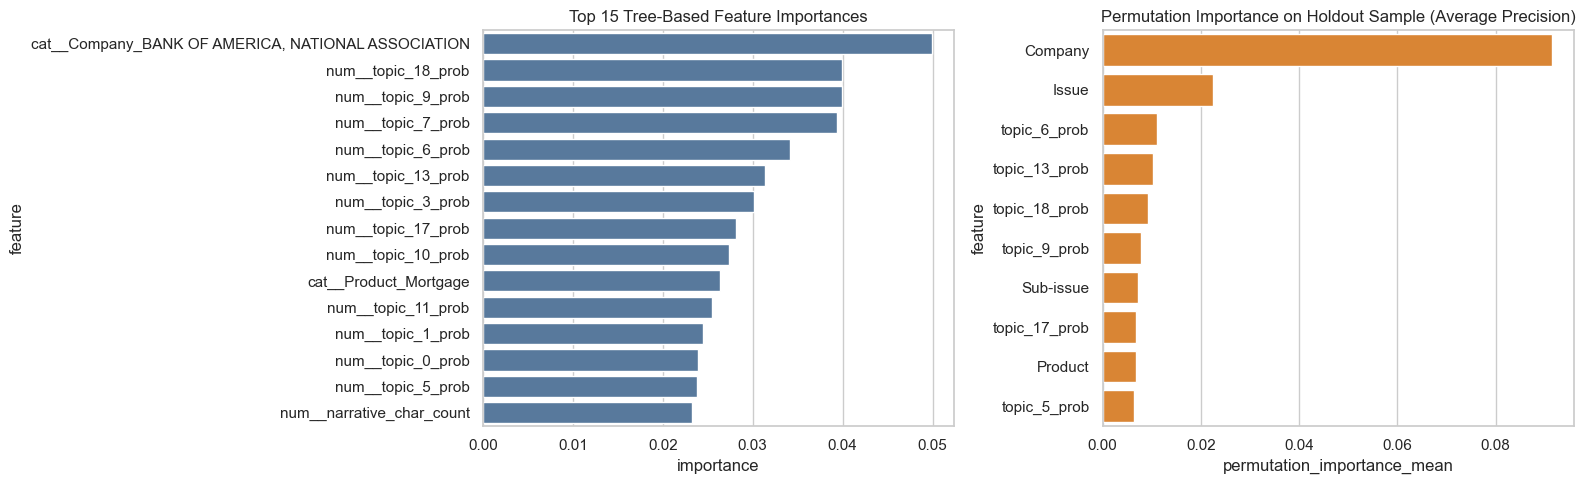

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=feature_importance_df.head(15), x="importance", y="feature", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 15 Tree-Based Feature Importances")

sns.barplot(data=perm_df.head(10), x="permutation_importance_mean", y="feature", ax=axes[1], color="#F58518")
axes[1].set_title("Permutation Importance on Holdout Sample (Average Precision)")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_narrative_feature_importance_plots.png", dpi=200, bbox_inches="tight")


A strong evaluation should connect importance results back to modeling choices. In the final narrative-only notebook, the key question is whether complaint context, company context, and lightweight text features explain most of the monetary-relief signal once we limit the task to records where narratives are available for everyone in scope.

We can see above that we pretty much get idential feature importance and permutation importance scores from the narrative model when compared to our model created in the final_clean notebook.

### Ablation Analysis

Ablation testing measures how much the model depends on different groups of features. To keep runtime reasonable, this section uses a 3-fold CV summary on the training set and compares F1 after removing one feature family at a time.

Looking at the results below, it looks like overall including all the features we have results in the best outcome; however, the differences are minimal when removing certain features like the narrative or sentiment.

In [7]:
feature_groups = {
    "all_features": rf_features,
    "no_narrative_size": [f for f in rf_features if f not in {"narrative_char_count", "narrative_word_count"}],
    "no_sentiment": [f for f in rf_features if f != "narrative_sentiment_score"],
    "no_company": [f for f in rf_features if f != "Company"],
    "no_product_context": [f for f in rf_features if f not in {"Product", "Sub-product"}],
    "no_issue_context": [f for f in rf_features if f not in {"Issue", "Sub-issue"}],
}
if topic_cluster_features:
    feature_groups["no_topic_cluster"] = [f for f in rf_features if f not in set(topic_cluster_features)]

ablation_rows = []
fast_cv = StratifiedKFold(n_splits=FAST_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for label, cols in feature_groups.items():
    ablation_pipeline, _, _ = build_rf_pipeline(selected_features=cols, **best_rf_params)
    scores = cross_validate(
        ablation_pipeline,
        train_df[cols],
        y_train,
        scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
        cv=fast_cv,
        n_jobs=N_JOBS,
        return_train_score=False,
    )
    ablation_rows.append(
        {
            "ablation": label,
            "cv_mean_f1": scores["test_f1"].mean(),
            "cv_mean_precision": scores["test_precision"].mean(),
            "cv_mean_recall": scores["test_recall"].mean(),
            "feature_count": len(cols),
        }
    )

ablation_df = pd.DataFrame(ablation_rows).sort_values("cv_mean_f1", ascending=False).reset_index(drop=True)
baseline_f1 = ablation_df.loc[ablation_df["ablation"].eq("all_features"), "cv_mean_f1"].iloc[0]
ablation_df["f1_drop_vs_all_features"] = baseline_f1 - ablation_df["cv_mean_f1"]
ablation_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_ablation_results.csv", index=False)
display(ablation_df)


,ablation,cv_mean_f1,cv_mean_precision,cv_mean_recall,feature_count,f1_drop_vs_all_features
0,no_narrative_size,0.460449,0.370171,0.609079,33,-0.000035
1,all_features,0.460414,0.375472,0.595162,35,0.000000
2,no_sentiment,0.459800,0.372210,0.601392,34,0.000614
3,no_product_context,0.457893,0.376513,0.584228,33,0.002521
4,no_issue_context,0.439840,0.385883,0.511398,33,0.020574
5,no_company,0.413732,0.361994,0.482770,34,0.046682


### Sensitivity Analysis

Sensitivity analysis helps us understand whether the selected Random Forest is stable or fragile. Here we vary two influential hyperparameters, `max_depth` and `min_samples_leaf`, and track cross-validated F1. A stable model should not collapse from small changes around the selected setting.

We can see from the results below that varying these hyperparameters does not drastically improve or reduce overall performance in our model as the result is stable in the 0.4 range.

,max_depth,min_samples_leaf,cv_mean_f1,cv_mean_precision,cv_mean_recall
5,22,10,0.435733,0.357605,0.557825
8,None,10,0.434378,0.370156,0.525743
1,14,5,0.433833,0.342574,0.591650
2,14,10,0.433781,0.330209,0.632183
0,14,2,0.426496,0.350869,0.543900
4,22,5,0.416907,0.391866,0.445667
7,None,5,0.401577,0.419425,0.385479
3,22,2,0.343364,0.444484,0.280034
6,None,2,0.240656,0.498470,0.158668


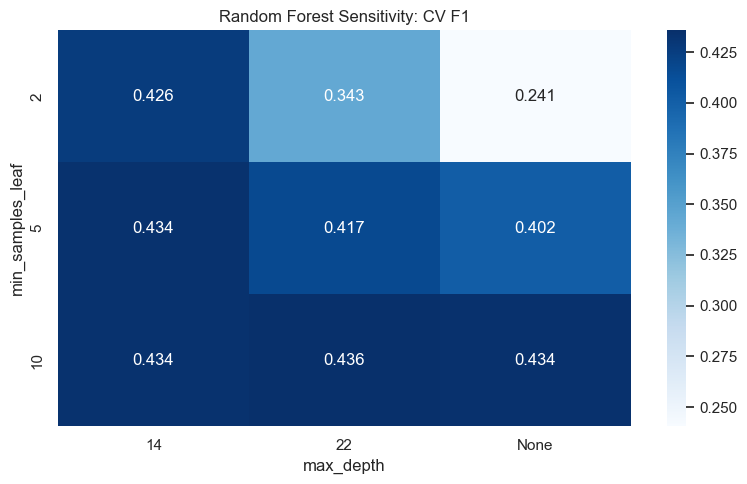

In [8]:
sensitivity_rows = []
sensitivity_train_df = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)
sensitivity_y = sensitivity_train_df[target_col]
for max_depth in [14, 22, None]:
    for min_samples_leaf in [2, 5, 10]:
        pipeline, _, _ = build_rf_pipeline(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=best_rf_params["min_samples_split"],
            max_features=best_rf_params["max_features"],
        )
        scores = cross_validate(
            pipeline,
            sensitivity_train_df[rf_features],
            sensitivity_y,
            scoring={"f1": "f1", "recall": "recall", "precision": "precision"},
            cv=fast_cv,
            n_jobs=N_JOBS,
            return_train_score=False,
        )
        sensitivity_rows.append(
            {
                "max_depth": str(max_depth),
                "min_samples_leaf": min_samples_leaf,
                "cv_mean_f1": scores["test_f1"].mean(),
                "cv_mean_precision": scores["test_precision"].mean(),
                "cv_mean_recall": scores["test_recall"].mean(),
            }
        )

sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values(["cv_mean_f1", "cv_mean_recall"], ascending=False)
sensitivity_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_sensitivity_results.csv", index=False)
display(sensitivity_df)

pivot_f1 = sensitivity_df.pivot(index="min_samples_leaf", columns="max_depth", values="cv_mean_f1")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="Blues")
plt.title("Random Forest Sensitivity: CV F1")
plt.ylabel("min_samples_leaf")
plt.xlabel("max_depth")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_narrative_sensitivity_heatmap.png", dpi=200, bbox_inches="tight")


### Tradeoff Analysis

Tradeoff analysis asks how the Random Forest behaves when we change decision thresholds or training data size. This is still useful even with a more balanced target, because threshold shifts can change the precision-recall tradeoff materially.

Similar to before, we see a very consistent trade off when looking at the size of data available and again only a slight marginal improvement by adjusting the decision threshold.

,setting,accuracy,precision,recall,f1,balanced_accuracy,average_precision
0,default_0.50,0.778167,0.374454,0.613040,0.464925,0.711004,0.413141
1,best_f1_0.503,0.780750,0.377569,0.608534,0.466004,0.710704,0.413141


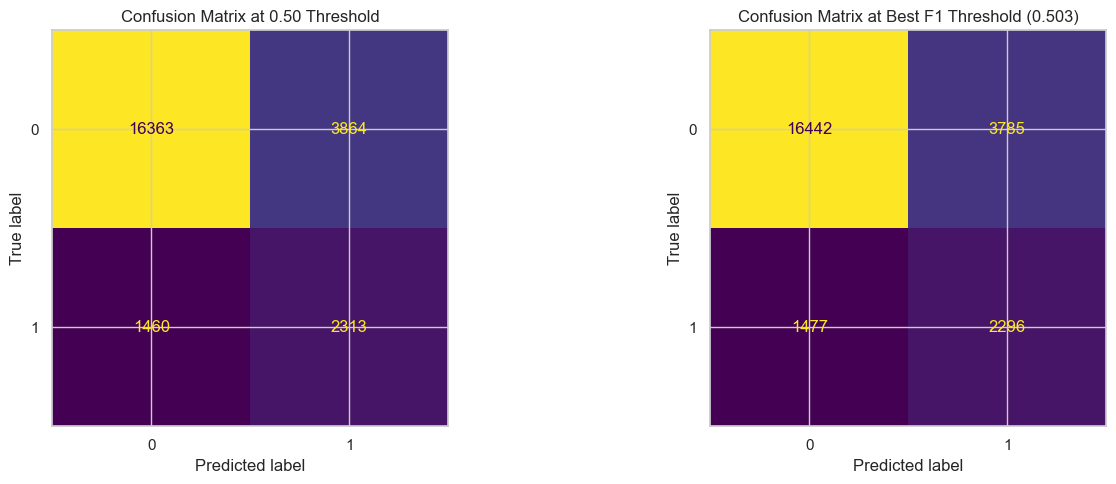

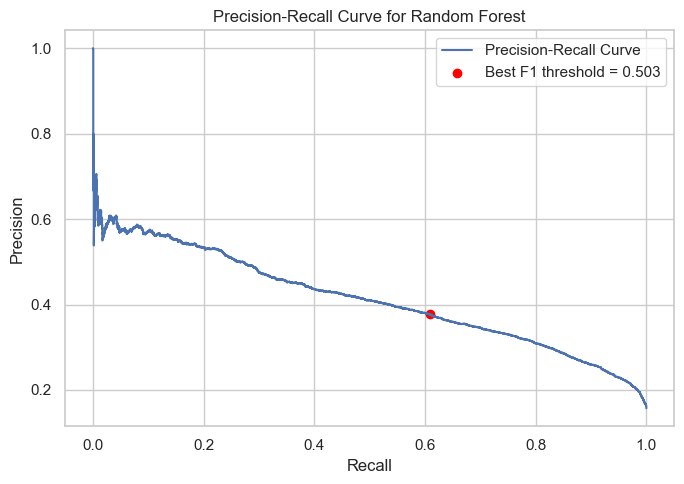

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_proba)
threshold_f1 = np.divide(
    2 * precisions[:-1] * recalls[:-1],
    precisions[:-1] + recalls[:-1],
    out=np.zeros_like(precisions[:-1]),
    where=(precisions[:-1] + recalls[:-1]) != 0,
)
best_threshold_idx = int(np.argmax(threshold_f1))
best_threshold = float(thresholds[best_threshold_idx])
threshold_pred = (test_proba >= best_threshold).astype(int)
threshold_metrics = score_predictions(y_test, threshold_pred, test_proba)

threshold_tradeoff_df = pd.DataFrame(
    {
        "setting": ["default_0.50", f"best_f1_{best_threshold:.3f}"],
        "accuracy": [holdout_metrics["accuracy"], threshold_metrics["accuracy"]],
        "precision": [holdout_metrics["precision"], threshold_metrics["precision"]],
        "recall": [holdout_metrics["recall"], threshold_metrics["recall"]],
        "f1": [holdout_metrics["f1"], threshold_metrics["f1"]],
        "balanced_accuracy": [holdout_metrics["balanced_accuracy"], threshold_metrics["balanced_accuracy"]],
        "average_precision": [holdout_metrics["average_precision"], threshold_metrics["average_precision"]],
    }
)
threshold_tradeoff_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_threshold_tradeoff.csv", index=False)
display(threshold_tradeoff_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix at 0.50 Threshold")
ConfusionMatrixDisplay.from_predictions(y_test, threshold_pred, ax=axes[1], colorbar=False)
axes[1].set_title(f"Confusion Matrix at Best F1 Threshold ({best_threshold:.3f})")
plt.tight_layout()
fig.savefig(VISUALS_DIR / "04_final_narrative_confusion_matrices.png", dpi=200, bbox_inches="tight")

plt.figure(figsize=(7, 5))
plt.plot(recalls, precisions, label="Precision-Recall Curve")
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx], color="red", label=f"Best F1 threshold = {best_threshold:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_narrative_precision_recall_curve.png", dpi=200, bbox_inches="tight")


,train_size,train_f1_mean,validation_f1_mean
0,3333,0.738892,0.392323
1,6666,0.726982,0.415757
2,9999,0.706972,0.421271
3,13332,0.692993,0.428258
4,16666,0.687048,0.434700


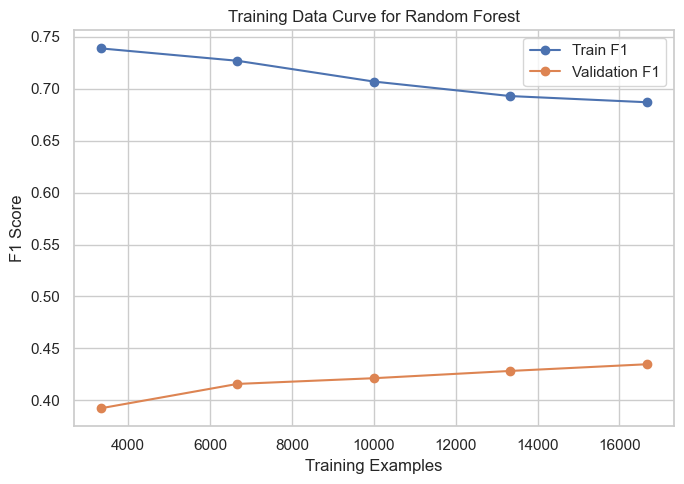

In [10]:
curve_train_df = train_df.sample(n=min(25000, len(train_df)), random_state=RANDOM_STATE)
curve_y = curve_train_df[target_col]
curve_pipeline, _, _ = build_rf_pipeline(**best_rf_params)
train_sizes, train_scores, valid_scores = learning_curve(
    curve_pipeline,
    curve_train_df[rf_features],
    curve_y,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=fast_cv,
    scoring="f1",
    n_jobs=N_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

learning_curve_df = pd.DataFrame(
    {
        "train_size": train_sizes,
        "train_f1_mean": train_scores.mean(axis=1),
        "validation_f1_mean": valid_scores.mean(axis=1),
    }
)
learning_curve_df.round(4).to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_learning_curve.csv", index=False)
display(learning_curve_df)

plt.figure(figsize=(7, 5))
plt.plot(learning_curve_df["train_size"], learning_curve_df["train_f1_mean"], marker="o", label="Train F1")
plt.plot(learning_curve_df["train_size"], learning_curve_df["validation_f1_mean"], marker="o", label="Validation F1")
plt.xlabel("Training Examples")
plt.ylabel("F1 Score")
plt.title("Training Data Curve for Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS_DIR / "04_final_narrative_learning_curve.png", dpi=200, bbox_inches="tight")


This section captures multiple project-required tradeoffs:

- precision versus recall as the classification threshold changes
- conservative default thresholding versus threshold tuning for minority-class detection
- training data size versus validation F1 through the learning curve

Together, these analyses help explain whether the model is limited more by representation, thresholding, or simply available data.


### Failure Analysis

Failure analysis focuses on specific mistakes rather than aggregate metrics. To satisfy the assignment requirement, we select at least three concrete failed predictions and group them into different categories. The goal is not just to note the error, but to reason about why it likely occurred and what future improvements could address it.


In [11]:
failure_df = test_df[[
    "Complaint ID",
    "Product",
    "Sub-product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "Consumer complaint narrative",
    target_col,
]].copy()
failure_df["predicted_label"] = test_pred
failure_df["predicted_proba"] = test_proba
failure_df["error_type"] = np.where(
    (failure_df[target_col] == 1) & (failure_df["predicted_label"] == 0),
    "false_negative",
    np.where(
        (failure_df[target_col] == 0) & (failure_df["predicted_label"] == 1),
        "false_positive",
        "correct",
    ),
)
failure_df["narrative_present"] = failure_df["Consumer complaint narrative"].fillna("").str.len().gt(0)
failure_df["narrative_word_count"] = failure_df["Consumer complaint narrative"].fillna("").str.split().str.len().fillna(0)

false_negative_examples = failure_df.loc[failure_df["error_type"].eq("false_negative")].sort_values("predicted_proba", ascending=False)
false_positive_examples = failure_df.loc[failure_df["error_type"].eq("false_positive")].sort_values("predicted_proba", ascending=False)

failure_examples = pd.concat(
    [
        false_negative_examples.head(1).assign(failure_category="likely systematic minority-class miss"),
        false_positive_examples.head(1).assign(failure_category="aggressive positive flag / ambiguous case"),
        false_negative_examples.sort_values("narrative_word_count").head(1).assign(failure_category="sparse-information edge case"),
    ],
    axis=0,
).drop_duplicates(subset=["Complaint ID"]).reset_index(drop=True)

failure_examples.to_csv(OUTPUT_TABLES_DIR / "04_final_narrative_failure_examples.csv", index=False)
display(failure_examples[[
    "Complaint ID",
    "failure_category",
    "error_type",
    target_col,
    "predicted_label",
    "predicted_proba",
    "Product",
    "Issue",
    "Sub-issue",
    "Company",
    "Submitted via",
    "narrative_present",
    "narrative_word_count",
]])


,Complaint ID,failure_category,error_type,target_relief,predicted_label,predicted_proba,Product,Issue,Sub-issue,Company,Submitted via,narrative_present,narrative_word_count
0,6799356,likely systematic minority-class miss,false_negative,1,0,0.499936,Credit card or prepaid card,Closing your account,Can't close your account,"Bread Financial Holdings, Inc.",Web,True,83
1,6541114,aggressive positive flag / ambiguous case,false_positive,0,1,0.837477,Credit card or prepaid card,Problem with a purchase shown on your statement,Card was charged for something you did not pur...,"BANK OF AMERICA, NATIONAL ASSOCIATION",Web,True,418
2,4139650,sparse-information edge case,false_negative,1,0,0.244925,Credit card or prepaid card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,JPMORGAN CHASE & CO.,Web,True,8
